 MLPClassifier (Rede Neural)

## Foco: Treinar um classificador de rede neural (Multi-layer Perceptron).

**Justificativa Estratégica:** Após a análise dos modelos de árvore e lineares, identificamos uma lacuna na detecção de ataques web raros e complexos. Os modelos de árvore (Random Forest, XGBoost) são eficazes no geral, mas falham em generalizar para essas classes. Os modelos lineares (Regressão Logística, SGD) são incapazes de capturar a complexidade não-linear do problema.

**Hipótese:** Uma rede neural, através do `MLPClassifier`, pode ser capaz de aprender os padrões não-lineares sutis que caracterizam os ataques web raros, de uma forma que os modelos baseados em árvores não conseguem. Se bem-sucedido, este modelo adicionará uma diversidade de "pensamento" crucial ao nosso ensemble final.

**Metodologia:** O `MLPClassifier` é altamente sensível à escala das features, portanto, o uso de dados padronizados (`StandardScaler`) é **obrigatório**.

### Importação das bibliotecas:

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### 2. Carregamento dos Artefatos e dos Dados

 1. Carregamos os artefatos (LabelEncoder, lista de features) para garantir consistência.
 2. Carregamos e limpamos os dados brutos.
 3. Aplicamos a **Padronização das Features** (`StandardScaler`), que é um
    pré-requisito não-negociável para o bom funcionamento de redes neurais.

In [2]:
# --- 1. Carrega os artefatos salvos ---

try:
    project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
except:
    project_root = os.getcwd()

model_dir = os.path.join(project_root, 'models')

# Carrega o codificador de rótulos e a lista de features
try:
    label_encoder = joblib.load(os.path.join(model_dir, 'label_encoder.joblib'))
    features_realistas = joblib.load(os.path.join(model_dir, 'features_realistas.joblib'))
    print("Artefatos (LabelEncoder e lista de features) carregados com sucesso.")
except FileNotFoundError:
    raise RuntimeError("ERRO: Artefatos do Notebook 01 não encontrados. Por favor, execute o notebook 01-RandomForest primeiro.")

# --- 2. Carrega e limpa os dados ---

caminho_dados = os.path.join(project_root, 'MachineLearningCSV', 'MachineLearningCVE')
todos_os_arquivos = glob.glob(os.path.join(caminho_dados, "*.csv"))

lista_de_dfs = []
for arquivo in todos_os_arquivos:
    df = pd.read_csv(arquivo, low_memory=False)
    lista_de_dfs.append(df)

dados = pd.concat(lista_de_dfs, axis=0, ignore_index=True)

# Limpeza
dados.columns = dados.columns.str.strip()
for col in dados.columns:
    if dados[col].dtype == 'object' and col != 'Label':
        dados[col] = pd.to_numeric(dados[col], errors='coerce')
dados.replace([np.inf, -np.inf], np.nan, inplace=True)
dados.dropna(inplace=True)

# Separação e codificação
X_bruto = dados.drop('Label', axis=1)
y_bruto = dados['Label']
y_codificado = label_encoder.transform(y_bruto)
X_realista = X_bruto[features_realistas]

print("\nDataset carregado e processado.")

# --- 3. Padronização das Features ---

print("Iniciando a padronização das features...")
scaler = StandardScaler()

# Padroniza todoo conjunto de features antes da divisão
X_padronizado = scaler.fit_transform(X_realista)

print("Padronização concluída.")

Artefatos (LabelEncoder e lista de features) carregados com sucesso.

Dataset carregado e processado.
Iniciando a padronização das features...
Padronização concluída.


### 3. Divisão dos Dados em Treino e Teste

 A etapa de divisão é a mesma, utilizando os dados padronizados (`X_padronizado`) para garantir que a rede neural receba os dados na escala correta, o que é crucial para uma convergência estável e eficiente do treinamento.

In [3]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_padronizado,  # <-- Usando os dados padronizados
    y_codificado,
    test_size=0.3,
    random_state=42,
    stratify=y_codificado
)

print("Divisão dos dados concluída.")
print(f"Shape do conjunto de treino (X_treino): {X_treino.shape}")
print(f"Shape do conjunto de teste (X_teste):   {X_teste.shape}")

Divisão dos dados concluída.
Shape do conjunto de treino (X_treino): (1979513, 14)
Shape do conjunto de teste (X_teste):   (848363, 14)


### 4. Treinamento do Modelo MLPClassifier

 Parâmetros importantes:
 - `hidden_layer_sizes=(100, 50)`: Esta é a **arquitetura** da nossa rede.
   Significa que teremos duas camadas ocultas: a primeira com 100 neurônios e a segunda com 50.
   É uma arquitetura robusta para começar, capaz de aprender padrões complexos.
 - `activation='relu'`: A função de ativação "Rectified Linear Unit". É a mais comum e eficiente para a maioria dos problemas.
 - `solver='adam'`: Um otimizador avançado que adapta a taxa de aprendizado.
 - `early_stopping=True`: Uma técnica contra overfitting. O modelo reserva uma parte dos dados de treino para validação e para o treinamento se a performance nesses dados de validação parar de melhorar.
 - `verbose=True`: Nos mostrará o progresso do treinamento a cada iteração (época).

In [4]:
print("Iniciando o treinamento do modelo MLPClassifier...")
print("AVISO: O treinamento pode levar alguns minutos.")

# Instancia o classificador de rede neural
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    random_state=42,
    max_iter=300,  # Número máximo de épocas
    early_stopping=True,  # Para o treino se não houver melhora
    validation_fraction=0.1, # Usa 10% do treino para validação
    n_iter_no_change=10, # Número de épocas sem melhora para parar
    verbose=True  # Mostra o progresso
)

# Treina o modelo usando os dados de treino completos e padronizados
mlp_model.fit(X_treino, y_treino)

print("\nTreinamento concluído.")

Iniciando o treinamento do modelo MLPClassifier...
AVISO: O treinamento pode levar alguns minutos.
Iteration 1, loss = 0.27595045
Validation score: 0.926250
Iteration 2, loss = 0.18643825
Validation score: 0.929276
Iteration 3, loss = 0.16910156
Validation score: 0.927690
Iteration 4, loss = 0.16275225
Validation score: 0.929059
Iteration 5, loss = 0.15907258
Validation score: 0.930342
Iteration 6, loss = 0.15641057
Validation score: 0.931059
Iteration 7, loss = 0.15435617
Validation score: 0.930609
Iteration 8, loss = 0.15205398
Validation score: 0.936040
Iteration 9, loss = 0.15116829
Validation score: 0.932564
Iteration 10, loss = 0.14980218
Validation score: 0.934691
Iteration 11, loss = 0.14822750
Validation score: 0.935611
Iteration 12, loss = 0.14734790
Validation score: 0.935676
Iteration 13, loss = 0.14599811
Validation score: 0.937202
Iteration 14, loss = 0.14425550
Validation score: 0.941324
Iteration 15, loss = 0.14310173
Validation score: 0.940890
Iteration 16, loss = 0.14

### 5. Avaliação do Modelo

 Agora, vamos submeter nossa rede neural ao mesmo processo de avaliação dos outros modelos.

 As perguntas que queremos responder são:
 1. Como a performance geral (F1-score ponderado) se compara aos nossos outros modelos (RF, XGBoost, CatBoost)?
 2. Mais importante: o `MLPClassifier` conseguiu um `recall` e `precision` melhores para as classes de `Web Attack`?
3. Ele conseguiu ser o "especialista" que estávamos procurando?

--- Relatório de Classificação (MLPClassifier) ---
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.95      0.97    681396
                       Bot       0.87      0.39      0.54       587
                      DDoS       0.80      0.82      0.81     38408
             DoS GoldenEye       0.00      0.00      0.00      3088
                  DoS Hulk       0.80      1.00      0.89     69037
          DoS Slowhttptest       0.97      0.12      0.22      1650
             DoS slowloris       0.96      0.27      0.42      1739
               FTP-Patator       0.87      1.00      0.93      2380
                Heartbleed       0.00      0.00      0.00         3
              Infiltration       0.00      0.00      0.00        11
                  PortScan       0.69      0.98      0.81     47641
               SSH-Patator       1.00      0.51      0.68      1769
  Web Attack � Brute Force       0.00      0.00      0.00       

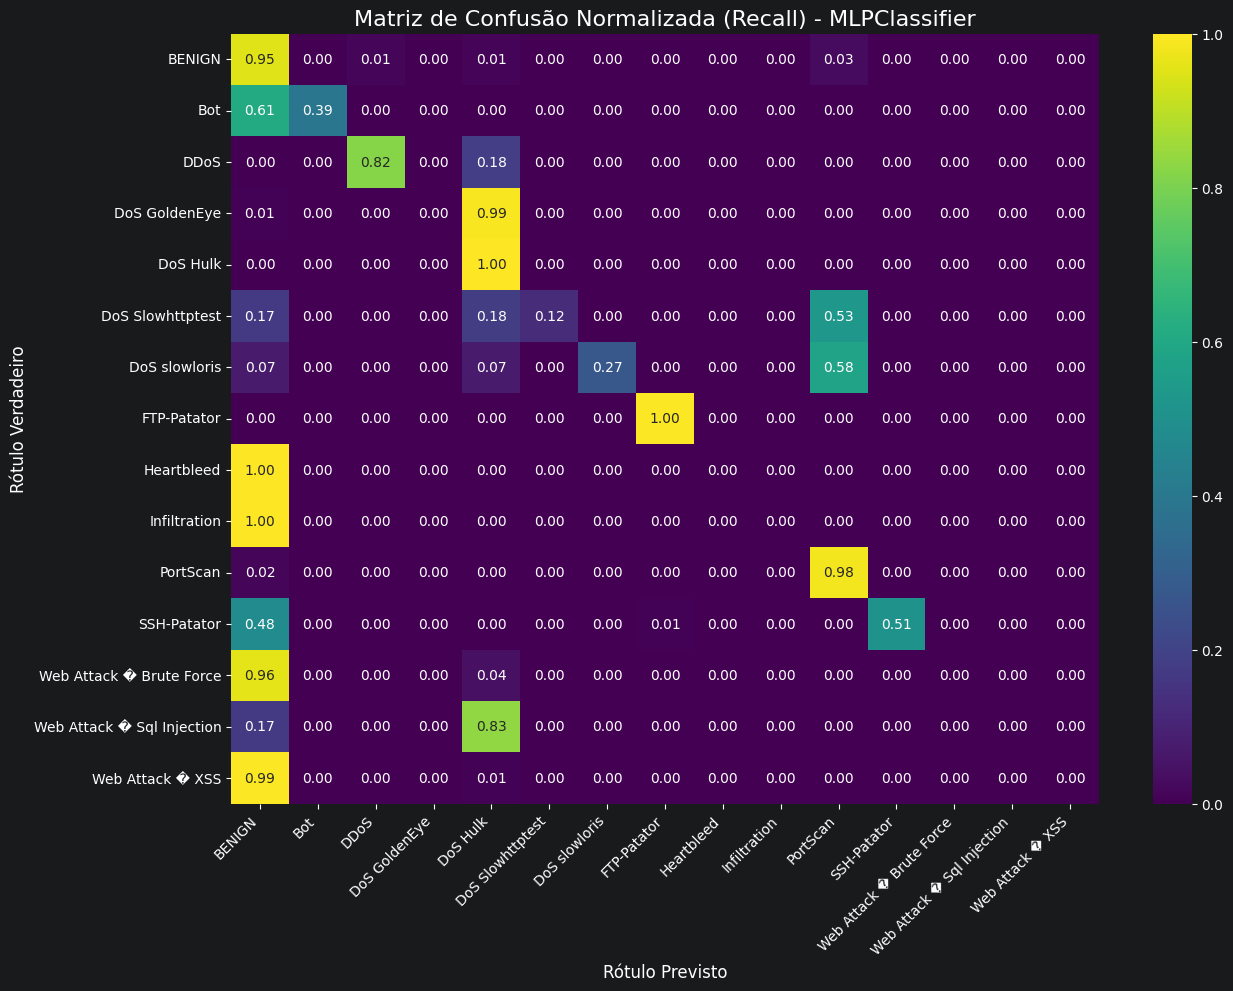

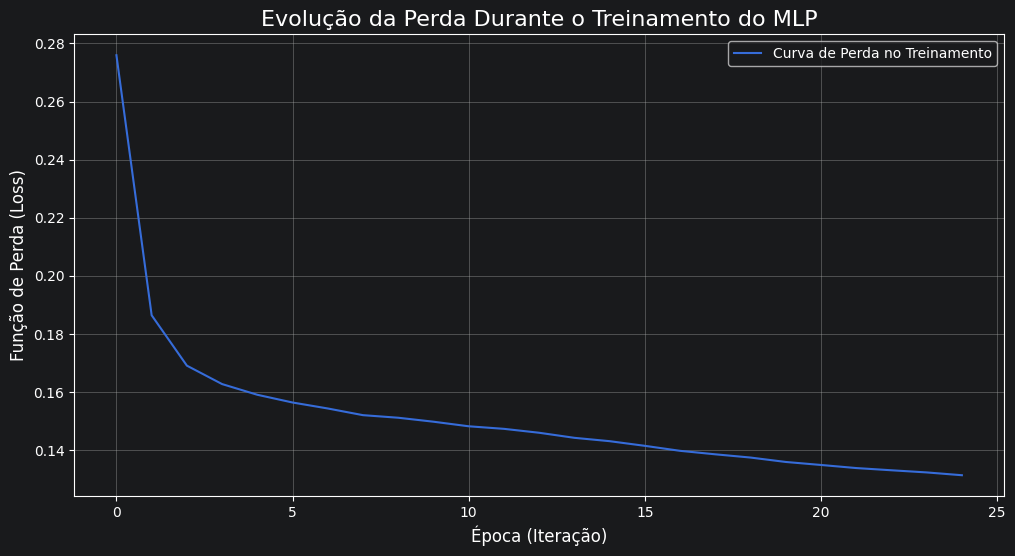

In [5]:
y_pred = mlp_model.predict(X_teste)
y_pred_proba = mlp_model.predict_proba(X_teste)

# --- Relatório de Classificação ---
print("--- Relatório de Classificação (MLPClassifier) ---")
print(classification_report(y_teste, y_pred, target_names=label_encoder.classes_.astype(str), zero_division=0))

# --- F1-Score Ponderado ---
f1 = f1_score(y_teste, y_pred, average='weighted')
print(f"\nF1-Score (Ponderado): {f1:.4f}")

# --- Matriz de Confusão (Normalizada/Recall) ---
cm_norm = confusion_matrix(y_teste, y_pred)
cm_norm = cm_norm.astype('float') / cm_norm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='viridis',
            xticklabels=label_encoder.classes_.astype(str),
            yticklabels=label_encoder.classes_.astype(str))
plt.title('Matriz de Confusão Normalizada (Recall) - MLPClassifier', fontsize=16)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# --- Curva de Perda do Treinamento ---
plt.figure(figsize=(12, 6))
plt.plot(mlp_model.loss_curve_, label='Curva de Perda no Treinamento')
plt.title('Evolução da Perda Durante o Treinamento do MLP', fontsize=16)
plt.xlabel('Época (Iteração)', fontsize=12)
plt.ylabel('Função de Perda (Loss)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


### 6. Salvando o Modelo MLPClassifier

 Embora não tenha se tornado o "especialista" em ataques web que esperávamos, o MLPClassifier provou ser um excelente modelo "generalista" com uma performance geral muito forte (F1 Ponderado de ~0.94).

 Sua abordagem de aprendizado, fundamentalmente diferente dos modelos de árvore, o torna um candidato ideal para adicionar diversidade e robustez ao nosso ensemble final. Ele será o quarto membro do nosso ensemble.

In [6]:
import os
import joblib

# --- Define o diretório de salvamento ---
try:
    project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
except:
    project_root = os.getcwd()

model_dir = os.path.join(project_root, 'models')

if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"Diretório criado: {model_dir}")

# --- Salva o modelo treinado ---
model_path = os.path.join(model_dir, 'mlp_model.joblib')
joblib.dump(mlp_model, model_path)
print(f"Modelo MLPClassifier salvo em: {model_path}")

# --- Verificação Final ---
print("\n--- Verificando arquivos salvos no diretório 'models' ---")
try:
    print(sorted(os.listdir(model_dir)))
except Exception as e:
    print(f"Não foi possível listar os arquivos: {e}")

Modelo MLPClassifier salvo em: /home/henrique/PycharmProjects/ndr-tcc/models/mlp_model.joblib

--- Verificando arquivos salvos no diretório 'models' ---
['catboost_model.joblib', 'features_realistas.joblib', 'label_encoder.joblib', 'mlp_model.joblib', 'random_forest_model.joblib', 'top_15_features.joblib', 'xgboost_model.joblib']
